# Day 4: Advanced Analytics & Anomaly Detection
**Hakeem • SparkCity**

Deliverables: a batch anomaly scoring and local alert system, predictive models with chronological validation, measured pipeline benchmarks, and a self-contained HTML dashboard.

Run all cells using the project's `.venv` kernel after `uv sync --dev`. This notebook reads a complete Day 3 snapshot and writes a unique `data/processed/day4/<run>` directory. Alerts are local files for review; no external notifications, S2 writes or automated operational responses occur.

## 1. Configuration and provenance
Select a Day 3 run or use the latest complete run. Algorithms use the installed PySpark ML library: standardized K-means distance for multivariate anomaly detection; linear regression and random forests for forecasting. This is not an Isolation Forest implementation or a streaming deployment.

Units and timezone remain as documented by Day 2/3. Synthetic data does not establish real-world alert thresholds or operational model accuracy. Training features are explicitly selected; Day 2 global outlier flags and Day 3 change-rate columns are not used as predictors.

In [1]:
import os
import sys
import json
import time
import hashlib
import platform
import base64
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.functions import vector_to_array
from pyspark.ml.evaluation import RegressionEvaluator
from sparkcityx.data_quality import validate_dataframe, get_validation_config

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start inside SparkCity_Capstone.")
java_home = Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
if not os.getenv("JAVA_HOME") and java_home.exists():
    os.environ["JAVA_HOME"] = str(java_home)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
spark = (SparkSession.builder.master("local[2]").appName("Hakeem-Day4")
         .config("spark.ui.enabled", "false")
         .config("spark.sql.shuffle.partitions", "4")
         .config("spark.sql.session.timeZone", "UTC").getOrCreate())
spark.conf.set("spark.sql.session.timeZone", "UTC")
spark.sparkContext.setLogLevel("ERROR")
DAY3_RUN = None
base = ROOT / "data/processed/day3"
complete = sorted(p.parent for p in base.glob("*/manifest.json")
                  if json.loads(p.read_text()).get("status") == "complete")
DAY3 = base / DAY3_RUN if DAY3_RUN else (complete[-1] if complete else None)
if DAY3 is None or not (DAY3 / "manifest.json").exists():
    raise RuntimeError("Complete Hakeem_day3.ipynb first.")
source_manifest = json.loads((DAY3 / "manifest.json").read_text())
if source_manifest.get("status") != "complete":
    raise ValueError("Selected Day 3 run is incomplete.")
if not source_manifest.get("day1_run") or not source_manifest.get("day2_run"):
    raise ValueError("Run the corrected Day 3 notebook first to establish the full source lineage.")
if source_manifest.get("outlier_policy") != "flag":
    raise ValueError("Use Day 2 flag-only outputs for modeling; global clipping could leak future distribution information.")
source_manifest_hash = hashlib.sha256((DAY3 / "manifest.json").read_bytes()).hexdigest()

def dataset_hash(path):
    digest = hashlib.sha256()
    for item in sorted(path.rglob("*")):
        if item.is_file():
            digest.update(str(item.relative_to(path)).encode())
            with item.open("rb") as handle:
                for block in iter(lambda: handle.read(1024 * 1024), b""):
                    digest.update(block)
    return digest.hexdigest()

input_hashes = {}
expected_names = {"traffic", "air_quality", "weather", "energy", "occupancy", "fiscal"}
if {r["dataset"] for r in source_manifest["features"]} != expected_names:
    raise ValueError("Day 3 must supply all six temporal feature datasets.")
for kind in sorted(expected_names):
    path = DAY3 / "features" / kind
    if not path.is_dir():
        raise FileNotFoundError(path)
    input_hashes[kind] = dataset_hash(path)
print("Lineage: Day 1 {} -> Day 2 {} -> Day 3 {}".format(
    source_manifest["day1_run"], source_manifest["day2_run"], DAY3.name))
if source_manifest.get("spark") != spark.version:
    print("Review Spark version difference:", source_manifest.get("spark"), spark.version)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUTPUT = ROOT / "data/processed/day4" / RUN_ID
OUTPUT.mkdir(parents=True, exist_ok=False)
SEED = 42
ANOMALY_COLUMNS = {
    "traffic": ["vehicle_count", "avg_speed"], "air_quality": ["pm25", "pm10", "no2", "co"],
    "weather": ["temperature", "humidity", "wind_speed", "pressure"],
    "energy": ["power_consumption", "voltage", "current", "power_factor"],
    "occupancy": ["occupied_rooms", "guests"], "fiscal": ["expense", "revenue"],
}
TARGETS = {"traffic": "vehicle_count", "air_quality": "pm25", "energy": "power_consumption"}
# Fit on first 60%, calibrate/select on next 20%, test on final 20% of elapsed span.
TRAIN_FRACTION, VALIDATION_END = 0.60, 0.80
ALERT_QUANTILE = 0.99
sns.set_theme(style="whitegrid")
print("Source:", DAY3)
print("Output:", OUTPUT)
print("Versions:", spark.version, sys.version.split()[0])

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/14 16:59:33 WARN Utils: Your hostname, Zipcoders-MacBook-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.88.25 instead (on interface en0)
26/09/14 16:59:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/14 16:59:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Lineage: Day 1 20260914T135810735977Z -> Day 2 20260914T135902169587Z -> Day 3 20260914T142210469836Z
Source: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day3/20260914T142210469836Z
Output: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day4/20260914T205935811311Z
Versions: 4.2.0 3.13.7


## 2. Input quality and time partitions
Recheck contracts and reject non-finite model inputs. Time boundaries are computed from the elapsed dataset span, separately per dataset. They are not random row splits.

For forecasting, both origin and target must belong to the same training/validation interval. Pairs crossing either boundary are purged. Final observations with no known next target cannot be evaluated. Report those exclusions explicitly.

In [2]:
def time_boundaries(df):
    row = df.agg(F.min("timestamp").cast("long").alias("start"),
                 F.max("timestamp").cast("long").alias("end")).first()
    span = row["end"] - row["start"]
    if span <= 0:
        raise ValueError("Need a nonzero time span")
    return (int(row["start"] + TRAIN_FRACTION * span),
            int(row["start"] + VALIDATION_END * span))

def split_observations(df, bounds):
    first, second = bounds
    epoch = F.col("timestamp").cast("long")
    return (df.filter(epoch < first), df.filter((epoch >= first) & (epoch < second)),
            df.filter(epoch >= second))

frames, boundaries = {}, {}
expected = {r["dataset"]: r["rows"] for r in source_manifest["features"]}
for kind, columns in ANOMALY_COLUMNS.items():
    # Read only columns needed here, removing dozens of unused Day 3 feature fields.
    required = get_validation_config(kind)["required_columns"]
    extra = ["zone_id", "zone_name", "zone_type", "zone_match_count"] if kind == "traffic" else []
    frame = spark.read.parquet(str(DAY3 / "features" / kind)).select(*required, *extra).cache()
    report = validate_dataframe(frame, kind)
    assert report["valid"] and report["record_count"] == expected[kind], kind
    for c in columns:
        assert frame.filter(F.isnan(c) | (F.abs(F.col(c)) == float("inf"))).count() == 0, (kind, c)
    frames[kind], boundaries[kind] = frame, time_boundaries(frame)
print("Validated", sum(expected.values()), "temporal input rows.")

Validated 216000 temporal input rows.


## 3. Anomaly scoring and local alerts
Fit a standard scaler and three-cluster K-means model on early data only. Score squared distance to the nearest center; calibrate the threshold at the validation-period 99th percentile, then hold it fixed for the test period.

Also fit per-measurement mean/standard deviation on training data. Absolute Z-score >3 is a separate review reason. These assumptions can be poor for skewed/multimodal data: alerts are candidates for investigation. Cluster IDs describe observation regimes, not stable sensor classes. Zero distance thresholds disable distance alerts rather than divide by zero.

Save models, training statistics, thresholds, every test score and alert reason. Stable alert IDs include model/run ID, dataset, sensor and timestamp; deduplicate these IDs when replaying a given saved model. A new training run deliberately has a new model ID. There are no incident labels, so precision/recall and false-positive rates are unknown.

In [3]:
def distance_score(model, df):
    scored = model.transform(df).withColumn("_scaled_array", vector_to_array("scaled"))
    centers = model.stages[-1].clusterCenters()
    distances = []
    for center in centers:
        term = F.lit(0.0)
        for index, value in enumerate(center):
            term = term + (F.col("_scaled_array")[index] - float(value)) ** 2
        distances.append(term)
    return scored.withColumn("distance_squared", F.least(*distances)).drop("_scaled_array")

def make_alerts(scored, kind, columns, stats, threshold, model_id):
    reasons = []
    if threshold > 0:
        reasons.append(F.when(F.col("distance_squared") > threshold, F.lit("cluster_distance")))
    for c in columns:
        mean, std = stats[c]["mean"], stats[c]["std"]
        if std and std > 0:
            reasons.append(F.when(F.abs((F.col(c) - mean) / std) > 3, F.lit("zscore:" + c)))
    key = get_validation_config(kind)["duplicate_columns"][0]
    reasons = reasons or [F.lit(None).cast("string")]
    result = (scored.withColumn("alert_reasons", F.concat_ws(";", *reasons))
              .withColumn("is_alert", F.col("alert_reasons") != "")
              .withColumn("severity", F.when(F.col("is_alert"), "review").otherwise("none"))
              .withColumn("model_id", F.lit(model_id))
              .withColumn("alert_id", F.sha2(F.concat_ws("|", F.lit(model_id), F.lit(kind),
                                                           F.col(key), F.col("timestamp").cast("string")), 256)))
    return result

# Deliberately extreme point and normal point exercise the alert path.
check_df = spark.createDataFrame([
    ("a", "2025-01-01", 100.0, 10.0), ("b", "2025-01-01", 1.0, 1.0)],
    "sensor_id string, timestamp string, distance_squared double, reading double")
check_alerts = make_alerts(check_df, "traffic", ["reading"], {"reading": {"mean": 1., "std": 1.}}, 5., "fixture")
assert check_alerts.filter("is_alert").count() == 1
assert "zscore:reading" in check_alerts.filter("is_alert").first()["alert_reasons"]
assert make_alerts(check_df, "traffic", [], {}, 0., "fixture").filter("is_alert").count() == 0

anomaly_audit, anomaly_config, alert_daily = [], {}, {}
for kind, frame in frames.items():
    train, calibration, test = split_observations(frame, boundaries[kind])
    counts = [part.count() for part in (train, calibration, test)]
    assert min(counts) >= 30 and sum(counts) == expected[kind], (kind, counts)
    columns = ANOMALY_COLUMNS[kind]
    pipeline = Pipeline(stages=[
        VectorAssembler(inputCols=columns, outputCol="assembled", handleInvalid="error"),
        StandardScaler(inputCol="assembled", outputCol="scaled", withMean=True, withStd=True),
        KMeans(featuresCol="scaled", predictionCol="cluster", k=3, seed=SEED, maxIter=15),
    ])
    model = pipeline.fit(train)
    calibration_scores = distance_score(model, calibration)
    threshold = float(calibration_scores.approxQuantile("distance_squared", [ALERT_QUANTILE], 0.001)[0])
    stats = {}
    for c in columns:
        r = train.agg(F.avg(c).alias("mean"), F.stddev_pop(c).alias("std")).first()
        stats[c] = r.asDict()
    scored = make_alerts(distance_score(model, test), kind, columns, stats, threshold, RUN_ID).cache()
    selected = scored.drop("assembled", "scaled").withColumn("dataset", F.lit(kind))
    selected = selected.withColumn("_day3_run_id", F.lit(DAY3.name))
    selected.write.mode("errorifexists").parquet(str(OUTPUT / "anomaly_scores" / kind))
    alerts = selected.filter("is_alert")
    alerts.write.mode("errorifexists").parquet(str(OUTPUT / "alerts" / kind))
    alert_count = alerts.count()
    persisted = spark.read.parquet(str(OUTPUT / "anomaly_scores" / kind))
    assert persisted.count() == counts[2]
    assert spark.read.parquet(str(OUTPUT / "alerts" / kind)).count() == alert_count
    assert alerts.select("alert_id").distinct().count() == alert_count
    model.write().save(str(OUTPUT / "models" / ("anomaly_" + kind)))
    # Verify persisted model can reproduce scores on a deterministic sample.
    sample = test.orderBy("timestamp", get_validation_config(kind)["duplicate_columns"][0]).limit(5)
    reloaded = PipelineModel.load(str(OUTPUT / "models" / ("anomaly_" + kind)))
    a = distance_score(model, sample).select("distance_squared").collect()
    b = distance_score(reloaded, sample).select("distance_squared").collect()
    assert np.allclose([r[0] for r in a], [r[0] for r in b])
    replay = make_alerts(distance_score(reloaded, sample), kind, columns, stats, threshold, RUN_ID)
    original_alerts = make_alerts(distance_score(model, sample), kind, columns, stats, threshold, RUN_ID)
    check_cols = ["alert_id", "alert_reasons", "severity"]
    assert original_alerts.select(*check_cols).exceptAll(replay.select(*check_cols)).count() == 0
    anomaly_audit.append({"dataset": kind, "train_rows": counts[0], "calibration_rows": counts[1],
                          "test_rows": counts[2], "alert_rows": alert_count,
                          "alert_rate": alert_count / counts[2], "distance_threshold": threshold})
    anomaly_config[kind] = {"columns": columns, "training_stats": stats, "threshold": threshold,
                            "time_boundaries_epoch": boundaries[kind], "model_id": RUN_ID}
    alert_daily[kind] = (selected.groupBy(F.to_date("timestamp").alias("date"))
                         .agg(F.sum(F.col("is_alert").cast("long")).alias("alerts"),
                              F.count("*").alias("observations")).orderBy("date").toPandas())
    scored.unpersist()
    print(kind, "test alerts:", alert_count, "/", counts[2])
anomaly_df = pd.DataFrame(anomaly_audit)
anomaly_df.to_csv(OUTPUT / "anomaly_summary.csv", index=False)
(OUTPUT / "anomaly_config.json").write_text(json.dumps(anomaly_config, indent=2))
display(anomaly_df)

traffic test alerts: 114 / 7200
air_quality test alerts: 80 / 7200
weather test alerts: 89 / 7200
energy test alerts: 110 / 7200
occupancy test alerts: 36 / 7200
fiscal test alerts: 29 / 7200


,dataset,train_rows,calibration_rows,test_rows,alert_rows,alert_rate,distance_threshold
0,traffic,21600,7200,7200,114,0.015833,3.743813
1,air_quality,21600,7200,7200,80,0.011111,5.538682
2,weather,21600,7200,7200,89,0.012361,6.029585
3,energy,21600,7200,7200,110,0.015278,6.484810
4,occupancy,21600,7200,7200,36,0.005000,1.845471
5,fiscal,21600,7200,7200,29,0.004028,2.699561


## 4. Next-observation predictive models
Predict the next reading for the same sensor: traffic vehicle count, PM2.5 and energy consumption. Horizons are the actual gaps between observations, not one-hour forecasts. Current measurements and calendar features are available at the forecast origin.

Compare training-mean and persistence baselines, linear regression and a small random forest. Choose by validation RMSE; evaluate the chosen model and baselines on the untouched test period. Do not select by test score. Training-mean and persistence may win; the report records that honestly. Model estimates are not clipped to physical bounds, so inspect predictions before operational use.

Sensor identity and future values are not predictors. Initial observations remain usable because these models do not require missing lag features. This fixed experiment is not extensive hyperparameter tuning.

In [4]:
def forecast_inputs(df):
    """Known-at-origin predictors; usable without labels or future timestamps."""
    return (df.withColumn("hour_sin", F.sin(2 * np.pi * F.hour("timestamp") / 24))
            .withColumn("hour_cos", F.cos(2 * np.pi * F.hour("timestamp") / 24))
            .withColumn("weekday_sin", F.sin(2 * np.pi * (F.dayofweek("timestamp") - 1) / 7))
            .withColumn("weekday_cos", F.cos(2 * np.pi * (F.dayofweek("timestamp") - 1) / 7)))

def predict_saved_forecast(data, config, model_directory, kind):
    """Apply the selected saved rule/model using current observations only."""
    prepared = forecast_inputs(data)
    selected = config["selected"]
    if selected == "training_mean":
        return prepared.withColumn("prediction", F.lit(config["training_mean"]))
    if selected == "persistence":
        return prepared.withColumn("prediction", F.col(config["persistence_column"]).cast("double"))
    model = PipelineModel.load(str(model_directory / (kind + "_" + selected)))
    return model.transform(prepared)

def forecast_pairs(df, kind, target, bounds):
    key = get_validation_config(kind)["duplicate_columns"][0]
    order = Window.partitionBy(key).orderBy("timestamp")
    pairs = (df.withColumn("label", F.lead(target).over(order))
             .withColumn("target_timestamp", F.lead("timestamp").over(order))
             .withColumn("horizon_hours", (F.col("target_timestamp").cast("long") -
                                           F.col("timestamp").cast("long")) / 3600)
)
    pairs = forecast_inputs(pairs)
    known = pairs.filter(F.col("label").isNotNull())
    first, second = bounds
    origin, future = F.col("timestamp").cast("long"), F.col("target_timestamp").cast("long")
    train = known.filter((origin < first) & (future < first))
    valid = known.filter((origin >= first) & (origin < second) & (future < second))
    test = known.filter(origin >= second)
    return pairs, train, valid, test

def regression_metrics(df):
    return {name: RegressionEvaluator(labelCol="label", predictionCol="prediction",
                                      metricName=name).evaluate(df)
            for name in ("rmse", "mae", "r2")}

# Ensure a future label crossing a boundary cannot enter training.
fixture = spark.createDataFrame([("a", f"2025-01-{d:02d} 00:00:00", float(d))
                                for d in (1, 2, 3, 4, 5, 6)],
                               "sensor_id string, timestamp string, vehicle_count double")
fixture = fixture.withColumn("timestamp", F.to_timestamp("timestamp"))
cut1 = int(datetime(2025, 1, 3, tzinfo=timezone.utc).timestamp())
cut2 = int(datetime(2025, 1, 5, tzinfo=timezone.utc).timestamp())
_, tr, va, te = forecast_pairs(fixture, "traffic", "vehicle_count", (cut1, cut2))
assert tr.count() == va.count() == te.count() == 1
assert tr.first()["label"] == 2. and te.first()["label"] == 6.
perfect = spark.createDataFrame([(1., 1.), (2., 2.), (3., 3.)], ["label", "prediction"])
assert regression_metrics(perfect)["rmse"] == 0.

validation_rows, test_rows, forecast_audit, model_config, forecast_daily = [], [], [], {}, {}
for kind, target in TARGETS.items():
    pairs, train, valid, test = forecast_pairs(frames[kind], kind, target, boundaries[kind])
    train, valid, test = train.cache(), valid.cache(), test.cache()
    counts = [part.count() for part in (train, valid, test)]
    assert min(counts) >= 30, (kind, counts)
    assert train.agg(F.max("target_timestamp").cast("long")).first()[0] < boundaries[kind][0]
    assert valid.agg(F.max("target_timestamp").cast("long")).first()[0] < boundaries[kind][1]
    training_mean = float(train.agg(F.avg("label")).first()[0])
    predictors = ANOMALY_COLUMNS[kind] + ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"]
    models = {}
    models["linear"] = Pipeline(stages=[
        VectorAssembler(inputCols=predictors, outputCol="features"),
        LinearRegression(featuresCol="features", labelCol="label", regParam=0.1, maxIter=30)])
    models["random_forest"] = Pipeline(stages=[
        VectorAssembler(inputCols=predictors, outputCol="features"),
        RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20,
                              maxDepth=5, seed=SEED, minInstancesPerNode=10)])
    fitted = {name: estimator.fit(train) for name, estimator in models.items()}
    def predict(name, data):
        if name == "persistence":
            return data.withColumn("prediction", F.col(target).cast("double"))
        if name == "training_mean":
            return data.withColumn("prediction", F.lit(training_mean))
        return fitted[name].transform(data)
    candidates = ["training_mean", "persistence", "linear", "random_forest"]
    scores = {}
    for name in candidates:
        metrics = regression_metrics(predict(name, valid))
        if not np.isfinite(metrics["rmse"]):
            raise ValueError(f"{kind}/{name}: invalid validation RMSE")
        scores[name] = metrics["rmse"]
        validation_rows.append({"dataset": kind, "model": name, "rows": counts[1], **metrics})
    chosen = min(scores, key=scores.get)
    for name in dict.fromkeys(["training_mean", "persistence", chosen]):
        metrics = regression_metrics(predict(name, test))
        test_rows.append({"dataset": kind, "model": name, "selected": name == chosen,
                          "rows": counts[2], **metrics})
    key = get_validation_config(kind)["duplicate_columns"][0]
    predictions = predict(chosen, test).select(key, "timestamp", "target_timestamp",
                                               "horizon_hours", "label", "prediction")
    predictions.write.mode("errorifexists").parquet(str(OUTPUT / "predictions" / kind))
    persisted = spark.read.parquet(str(OUTPUT / "predictions" / kind))
    assert persisted.count() == counts[2]
    forecast_daily[kind] = (persisted.groupBy(F.to_date("target_timestamp").alias("date"))
                            .agg(F.avg("label").alias("actual"), F.avg("prediction").alias("predicted"))
                            .orderBy("date").toPandas())
    for name, model in fitted.items():
        model.write().save(str(OUTPUT / "models" / (kind + "_" + name)))
    horizon = pairs.filter("label IS NOT NULL").approxQuantile("horizon_hours", [.5], .001)[0]
    no_target = pairs.filter("label IS NULL").count()
    assert pairs.filter("label IS NOT NULL AND horizon_hours <= 0").count() == 0
    purged = expected[kind] - no_target - sum(counts)
    assert purged >= 0
    forecast_audit.append({"dataset": kind, "input_rows": expected[kind], "train_rows": counts[0],
                           "validation_rows": counts[1], "test_rows": counts[2],
                           "no_future_target": no_target,
                           "purged_boundary_pairs": expected[kind] - no_target - sum(counts),
                           "median_horizon_hours": horizon, "selected": chosen})
    model_config[kind] = {"target": target, "predictors": predictors, "selected": chosen,
                           "training_mean": training_mean, "persistence_column": target,
                           "time_boundaries_epoch": boundaries[kind]}
    # Compare saved inference with exported predictions, joined by keys (not row order).
    sample_predictions = persisted.orderBy("timestamp", key).limit(10)
    origins = sample_predictions.select(key, "timestamp").join(frames[kind], [key, "timestamp"])
    restored = predict_saved_forecast(origins, model_config[kind], OUTPUT / "models", kind)
    comparison = restored.select(key, "timestamp", F.col("prediction").alias("restored_prediction")).join(
        sample_predictions.select(key, "timestamp", "prediction"), [key, "timestamp"])
    assert comparison.count() == sample_predictions.count()
    error = comparison.agg(F.max(F.abs(F.col("prediction") - F.col("restored_prediction")))).first()[0]
    assert error < 1e-10, (kind, error)
    print(kind, "selected:", chosen, "horizon:", horizon, "hours; saved inference verified")
    train.unpersist(); valid.unpersist(); test.unpersist()
validation_df, test_df = pd.DataFrame(validation_rows), pd.DataFrame(test_rows)
validation_df.to_csv(OUTPUT / "validation_metrics.csv", index=False)
test_df.to_csv(OUTPUT / "test_metrics.csv", index=False)
pd.DataFrame(forecast_audit).to_csv(OUTPUT / "forecast_split_audit.csv", index=False)
(OUTPUT / "forecast_config.json").write_text(json.dumps(model_config, indent=2))
display(test_df)
display(pd.DataFrame(forecast_audit))

traffic selected: random_forest horizon: 250.0 hours; saved inference verified
air_quality selected: random_forest horizon: 450.0 hours; saved inference verified
energy selected: random_forest horizon: 400.0 hours; saved inference verified


,dataset,model,selected,rows,rmse,mae,r2
0,traffic,training_mean,False,4200,36.065280,29.235095,-1.310563e-03
1,traffic,persistence,False,4200,50.210507,39.663571,-9.407938e-01
2,traffic,random_forest,True,4200,33.306472,27.981661,1.460205e-01
3,air_quality,training_mean,False,5400,8.159293,7.036475,-5.635020e-07
4,air_quality,persistence,False,5400,11.442231,9.343800,-9.666025e-01
5,air_quality,random_forest,True,5400,8.157036,7.031563,5.526041e-04
6,energy,training_mean,False,4800,21.730527,17.365936,-1.164981e-03
7,energy,persistence,False,4800,31.535928,24.917737,-1.108513e+00
8,energy,random_forest,True,4800,21.070430,16.884557,5.873494e-02


,dataset,input_rows,train_rows,validation_rows,test_rows,no_future_target,purged_boundary_pairs,median_horizon_hours,selected
0,traffic,36000,18600,4200,4200,3000,6000,250.0,random_forest
1,air_quality,36000,19800,5400,5400,1800,3600,450.0,random_forest
2,energy,36000,19200,4800,4800,2400,4800,400.0,random_forest


## 5. Pipeline optimization and measured benchmarks
Benchmark the same daily energy aggregation on the same projected input, with and without Spark caching. Force full result collection, check numerical output equivalence, warm up once, then run three uncached trials followed by three cached trials. This order prevents Spark from substituting a cached plan into the uncached test; timing order remains a limitation. Cache materialization time is reported separately, as is a three-query workload cost including setup.

This measures repeated-query caching on this machine. It does not claim a universal speedup, cold-disk performance or scalability. The OS file cache and JVM remain warm. Four shuffle partitions and two local workers are explicit small-data settings, not tuned production recommendations.

In [5]:
for frame in frames.values():
    frame.unpersist(blocking=True)
def benchmark_query(df):
    return (df.groupBy(F.to_date("timestamp").alias("day"))
            .agg(F.sum("power_consumption").alias("total"),
                 F.avg("power_consumption").alias("mean"),
                 F.count("*").alias("n")).orderBy("day"))

def timed_collect(df):
    start = time.perf_counter()
    rows = df.collect()
    return time.perf_counter() - start, rows

path = str(DAY3 / "features/energy")
input_projection = spark.read.parquet(path).select("timestamp", "power_consumption")
reference = benchmark_query(input_projection).collect()  # Warm JVM and filesystem.
uncached_times = []
# Complete uncached trials before caching: Spark cache substitution could otherwise
# make an equivalent 'uncached' logical plan hit the cache.
for _ in range(3):
    seconds, result = timed_collect(benchmark_query(input_projection))
    assert len(result) == len(reference)
    assert [r["day"] for r in result] == [r["day"] for r in reference]
    assert np.allclose([r["mean"] for r in result], [r["mean"] for r in reference])
    assert np.allclose([r["total"] for r in result], [r["total"] for r in reference])
    assert [r["n"] for r in result] == [r["n"] for r in reference]
    uncached_times.append(seconds)
cached = input_projection.cache()
start = time.perf_counter()
cached_rows = cached.count()
materialization_seconds = time.perf_counter() - start
cached_times = []
for _ in range(3):
    seconds, result = timed_collect(benchmark_query(cached))
    assert [r["day"] for r in result] == [r["day"] for r in reference]
    assert [r["n"] for r in result] == [r["n"] for r in reference]
    assert np.allclose([r["total"] for r in result], [r["total"] for r in reference])
    assert np.allclose([r["mean"] for r in result], [r["mean"] for r in reference])
    cached_times.append(seconds)
cached.unpersist(blocking=True)
benchmark = {
    "rows": cached_rows, "repeats": 3, "uncached_seconds": uncached_times,
    "cached_seconds": cached_times, "cache_materialization_seconds": materialization_seconds,
    "uncached_median_seconds": float(np.median(uncached_times)),
    "cached_median_seconds": float(np.median(cached_times)),
    "three_query_uncached_seconds": sum(uncached_times),
    "three_query_cached_with_setup_seconds": materialization_seconds + sum(cached_times),
    "warm_query_speed_ratio": float(np.median(uncached_times) / np.median(cached_times)),
    "platform": platform.platform(), "cpu_count": os.cpu_count(),
    "spark_master": spark.sparkContext.master, "shuffle_partitions": spark.conf.get("spark.sql.shuffle.partitions"),
    "ordering": "warmup, 3 uncached trials, cache materialization, 3 cached trials",
}
assert cached_rows == expected["energy"]
(OUTPUT / "benchmarks.json").write_text(json.dumps(benchmark, indent=2))
display(pd.DataFrame({"uncached_seconds": uncached_times, "cached_seconds": cached_times}))
print("Cache setup seconds:", materialization_seconds)
print("Three-query cost:", benchmark["three_query_uncached_seconds"],
      "uncached;", benchmark["three_query_cached_with_setup_seconds"], "cached including setup.")

,uncached_seconds,cached_seconds
0,0.083243,0.082478
1,0.070144,0.064230
2,0.061861,0.082451


Cache setup seconds: 0.06859529099892825
Three-query cost: 0.21524883499660064 uncached; 0.29775391600560397 cached including setup.


## 6. Advanced analytics dashboard and findings
Charts show test-period alert rates, forecasts by target date, test RMSE per task and measured query times. Error scales are dataset-specific; do not compare RMSE across different units. Daily forecast means are only a visualization; metrics above are evaluated on individual sensor predictions.

An anomaly alert is a review request. Inspect its measurement values, cluster, timestamp, model version and reasons. Confirm units and sensor context before taking action. No real-world alert accuracy is inferred from an unsupervised alert rate.

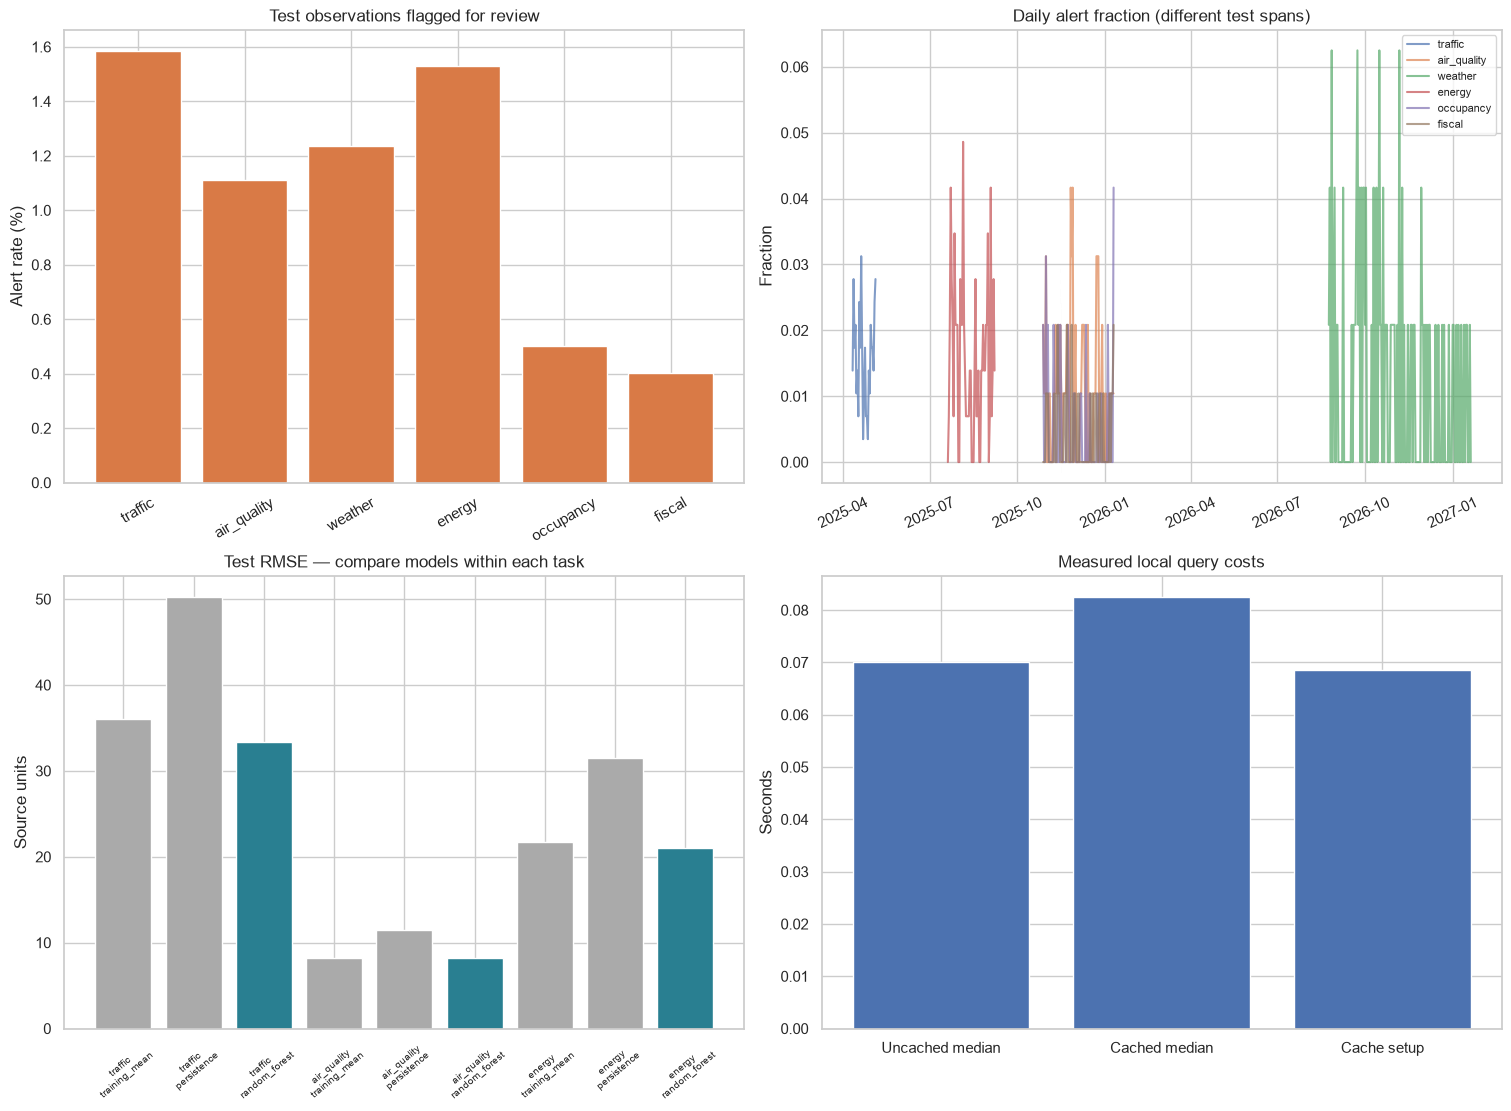

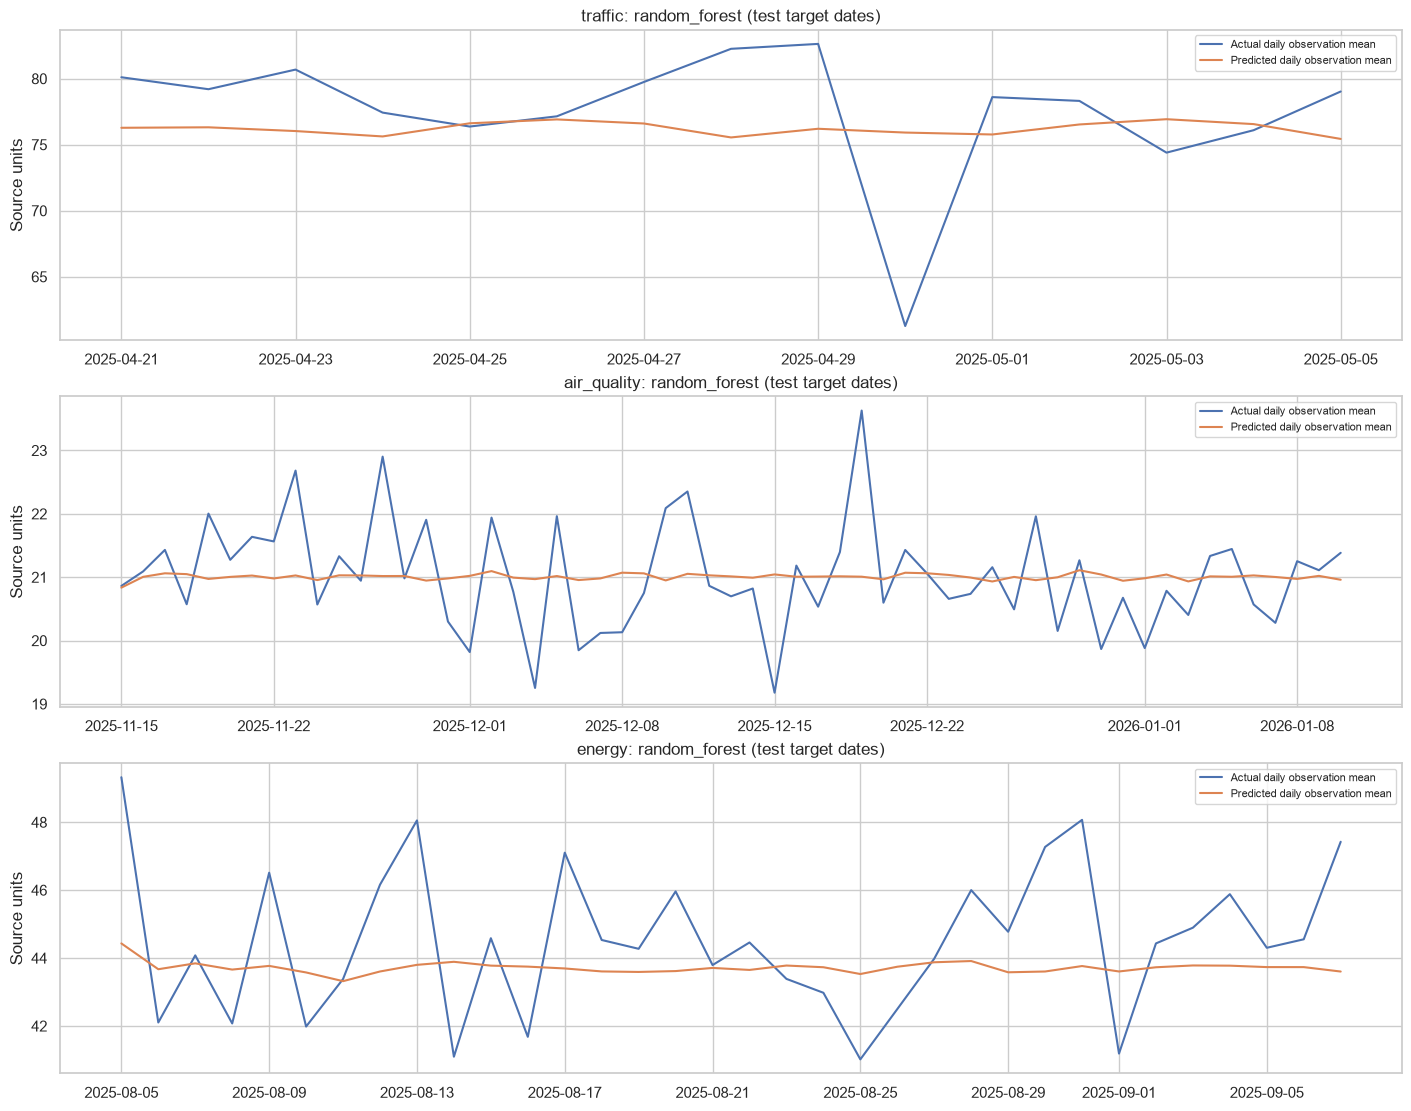

# Day 4 findings

Source Day 3 run: 20260914T142210469836Z

## Anomalies
K-means distances calibrated on validation data plus training Z-score rules.
No labeled incidents: precision, recall and false-positive rates are unknown.
- traffic: 114/7200 test observations flagged (1.58%).
- air_quality: 80/7200 test observations flagged (1.11%).
- weather: 89/7200 test observations flagged (1.24%).
- energy: 110/7200 test observations flagged (1.53%).
- occupancy: 36/7200 test observations flagged (0.50%).
- fiscal: 29/7200 test observations flagged (0.40%).

## Forecasts
Selection uses validation RMSE only; the test interval is held out.
- traffic: random_forest, horizon 250.0h; test RMSE=33.3065, MAE=27.9817, R²=0.1460.
- air_quality: random_forest, horizon 450.0h; test RMSE=8.1570, MAE=7.0316, R²=0.0006.
- energy: random_forest, horizon 400.0h; test RMSE=21.0704, MAE=16.8846, R²=0.0587.

## Performance
Warm-query speed ratio (uncached/cached): 0.85.
Three-query workload: 0.2152s uncached; 

In [6]:
charts = []
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
axes[0, 0].bar(anomaly_df["dataset"], 100 * anomaly_df["alert_rate"], color="#d97a46")
axes[0, 0].set(title="Test observations flagged for review", ylabel="Alert rate (%)")
axes[0, 0].tick_params(axis="x", rotation=30)
for kind, data in alert_daily.items():
    axes[0, 1].plot(pd.to_datetime(data["date"]), data["alerts"] / data["observations"], label=kind, alpha=.7)
axes[0, 1].set(title="Daily alert fraction (different test spans)", ylabel="Fraction")
axes[0, 1].legend(fontsize=8)
axes[0, 1].tick_params(axis="x", rotation=25)
labels = test_df["dataset"] + "\n" + test_df["model"]
axes[1, 0].bar(labels, test_df["rmse"], color=["#297f91" if v else "#aaa" for v in test_df["selected"]])
axes[1, 0].set(title="Test RMSE — compare models within each task", ylabel="Source units")
axes[1, 0].tick_params(axis="x", rotation=40, labelsize=7)
axes[1, 1].bar(["Uncached median", "Cached median", "Cache setup"],
               [benchmark["uncached_median_seconds"], benchmark["cached_median_seconds"],
                benchmark["cache_materialization_seconds"]])
axes[1, 1].set(title="Measured local query costs", ylabel="Seconds")
path = OUTPUT / "advanced_dashboard.png"
fig.savefig(path, dpi=130); charts.append(path); plt.show(); plt.close(fig)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), constrained_layout=True)
for ax, (kind, data) in zip(axes, forecast_daily.items()):
    ax.plot(pd.to_datetime(data["date"]), data["actual"], label="Actual daily observation mean")
    ax.plot(pd.to_datetime(data["date"]), data["predicted"], label="Predicted daily observation mean")
    ax.set(title=f"{kind}: {model_config[kind]['selected']} (test target dates)", ylabel="Source units")
    ax.legend(fontsize=8)
path = OUTPUT / "forecast_dashboard.png"
fig.savefig(path, dpi=130); charts.append(path); plt.show(); plt.close(fig)

findings = ["# Day 4 findings", "", f"Source Day 3 run: {DAY3.name}", "",
            "## Anomalies", "K-means distances calibrated on validation data plus training Z-score rules.",
            "No labeled incidents: precision, recall and false-positive rates are unknown."]
for row in anomaly_audit:
    findings.append(f"- {row['dataset']}: {row['alert_rows']}/{row['test_rows']} test observations "
                    f"flagged ({row['alert_rate']:.2%}).")
findings += ["", "## Forecasts", "Selection uses validation RMSE only; the test interval is held out."]
for row in forecast_audit:
    metric = test_df[(test_df["dataset"] == row["dataset"]) & test_df["selected"]].iloc[0]
    findings.append(f"- {row['dataset']}: {row['selected']}, horizon {row['median_horizon_hours']:.1f}h; "
                    f"test RMSE={metric['rmse']:.4f}, MAE={metric['mae']:.4f}, R²={metric['r2']:.4f}.")
findings += ["", "## Performance",
             f"Warm-query speed ratio (uncached/cached): {benchmark['warm_query_speed_ratio']:.2f}.",
             f"Three-query workload: {benchmark['three_query_uncached_seconds']:.4f}s uncached; "
             f"{benchmark['three_query_cached_with_setup_seconds']:.4f}s cached including setup.",
             "Warm filesystem/JVM; uncached trials precede cached trials, so timing order is a limitation.",
             "", "## Scope", "Batch analysis of synthetic data. No streaming service or outbound alert integration.",
             "Units and timezone require confirmation. Validate models on real representative data before deployment."]
(OUTPUT / "findings.md").write_text("\n".join(findings) + "\n")
html = ['<!doctype html><html><head><meta charset="utf-8"><title>SparkCity Day 4</title>',
        '<style>body{font:16px system-ui;max-width:1200px;margin:40px auto;padding:0 20px}'
        'img{width:100%}section{overflow-x:auto}td,th{padding:8px;border:1px solid #ddd}'
        'table{border-collapse:collapse;font-size:13px}pre{white-space:pre-wrap}</style></head><body>',
        f'<h1>SparkCity Day 4</h1><p>Source: {DAY3.name} · Run: {RUN_ID}</p>',
        '<p>Local batch alerts and synthetic-data forecasts. Alert accuracy is unknown. '
        'Selection uses validation RMSE; forecast horizons span days.</p>']
for path in charts:
    html.append(f'<img alt="{path.stem}" src="data:image/png;base64,{base64.b64encode(path.read_bytes()).decode()}">')
for title, table in [("Anomaly alerts", anomaly_df), ("Validation metrics", validation_df),
                     ("Held-out test metrics", test_df), ("Forecast row accounting", pd.DataFrame(forecast_audit))]:
    html += [f'<h2>{title}</h2><section>', table.to_html(index=False), '</section>']
html += ['<h2>Benchmark</h2><pre>', json.dumps(benchmark, indent=2), '</pre></body></html>']
(OUTPUT / "dashboard.html").write_text("\n".join(html))
print((OUTPUT / "findings.md").read_text())

## 7. Model reuse and Day 5 handoff
For a saved anomaly model: load `models/anomaly_<dataset>` with `PipelineModel.load`, transform new contract-checked input through `distance_score`, then call `make_alerts` with the saved training statistics, threshold and model ID from `anomaly_config.json`. Do not refit preprocessing on incoming data.

For forecasts: read `forecast_config.json`. If the selected model is `training_mean` or `persistence`, apply that saved rule; otherwise load `models/<dataset>_<selected>`. Use `predict_saved_forecast(current_observations, saved_config[dataset], run_path / "models", dataset)`; it prepares the calendar fields and does not require future targets. Models consume current observations and forecast the next observation; they do not forecast a specified fixed horizon.

Write the complete manifest only after all stages pass. Retain model directories, configurations and the manifest together. Alerts contain no credentials. Day 5 can add reviewed database integration and scheduling; rerunning this notebook creates a new model version and output directory.

In [7]:
assert hashlib.sha256((DAY3 / "manifest.json").read_bytes()).hexdigest() == source_manifest_hash
assert input_hashes == {k: dataset_hash(DAY3 / "features" / k) for k in input_hashes}, "Day 3 inputs changed during this run."
manifest = {
    "status": "complete", "run_id": RUN_ID, "day3_run": DAY3.name,
    "day3_manifest_sha256": source_manifest_hash,
    "day1_run": source_manifest["day1_run"], "day2_run": source_manifest["day2_run"],
    "input_sha256": input_hashes, "outlier_policy": source_manifest["outlier_policy"],
    "spark": spark.version, "python": sys.version, "seed": SEED,
    "source_units": source_manifest.get("source_units"),
    "timestamp_semantics": source_manifest.get("timestamp_semantics"),
    "anomalies": anomaly_audit, "forecast_split_audit": forecast_audit,
    "model_selection": model_config, "benchmark": benchmark,
    "alert_delivery": "local Parquet only; review severity; no outbound notifications",
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Completed:", OUTPUT)
print("Dashboard:", OUTPUT / "dashboard.html")
# spark.stop() when finished using this kernel.


Completed: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day4/20260914T205935811311Z
Dashboard: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day4/20260914T205935811311Z/dashboard.html
